<a href="https://colab.research.google.com/github/Astmatik001/MEVD001/blob/main/labs/%D0%9B%D0%A03_%D0%9E%D0%B1%D0%B5%D1%81%D0%BF%D0%B5%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BA%D0%B0%D1%87%D0%B5%D1%81%D1%82%D0%B2%D0%B0_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Постановка задачи


**Цель работы:** исследование и обработка данных для повышения их качества.

**Краткое описание:** в лабораторной работе приводится поэтапный план изучения и обработки намеренно не предобработанных данных. Необходимо выполнить все этапы плана и оценить результаты преобразований.

# Данные



В папке [Data/lab3](https://drive.google.com/drive/folders/1437z7m5Ut4WUJOhJg1oZz13dtBpxgFKs?usp=share_link) расположена таблица `monster_com_job_sample.com` с данными о вакансиях. Также эти данные с описанием и примерами обработки можно найти на [kaggle](https://www.kaggle.com/code/ankkur13/perfect-dataset-to-get-the-hands-dirty/data#).

##### **Формат данных**

```
country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
United States of America,US,"",No,jobs.monster.com,"TeamSoft is seeing an IT Support Specialist to join our client in Madison, WI. The ideal candidate must have at least 6 years of experience in the field. They need to be familiar with a variety of the field's concepts, practices, and procedures as this position relies on extensive experience and judgment to plan and accomplish goals. Required Skills:вАҐ Call tracking softwareвАҐ Phone based technical supportвАҐ Problem documentation and communicationвАҐ Remote Desktop Management ToolsвАҐ Respond to customer requestsвАҐ General understanding of LANDeskвАҐ Microsoft Office 2007 SuiteFind out why TeamSoft is the Madison area's technology leader with over 200 IT consultants. Owned, operated, and managed by IT consultants, TeamSoft is the clear choice for your career. Join the TeamSoft family today!Did you know?вАҐ TeamSoft offers salaried options for many positions that include 5 weeks PTO and great benefits!вАҐ TeamSoft has been in business since 1996вАҐ TeamSoft's owners are local IT professionals who possess a wealth of experience in application development, business analysis, and project managementвАҐ TeamSoft's Recruiters are knowledgeable, friendly, and ready to help you make your next great career moveвАҐ TeamSoft offers a full benefits suite to all of our W2 consultants, including a 401k plan with a 100% vested 4% dollar for dollar matchвАҐ Our targeted selection process is designed to get to know your strengths and career interests and provide you with the best chance for success in your new positionвАҐ Our longest running consultant has been with us for 16 yearsвАҐ Consultants can participate in our charitable giving committee. To date, TeamSoft's charitable giving committee has donated over $100,000!TeamSoft is owned by local IT professionals. Our team also has deep experience with IT staffing. Our clients understand this and rely on our expertise. That is why TeamSoft is the Madison Area's largest privately owned IT consulting firm, with more than 200 current consultants! With over 50 active clients, TeamSoft will give you the greatest exposure to the widest range of IT careers.Our owners possess a combined 60+ years of IT consulting experience. Our recruiting and Account Management staff are very well-versed in our client markets. We get you. We know you. We know what you do every day. And we know what you deal with on the job.You take your career seriously and so do we. At TeamSoft you are not just a resume or number. Our goal is to create long-term partnerships with each of our consultants, and according to feedback from many of them, we are very good at this. Click HERE to see what our consultants have to say about working with TeamSoft.TeamSoft -- Promote yourself!TeamSoft is an equal employment opportunity employer functioning under an Affirmative Action Plan.",IT Support Technician Job in Madison,Full Time Employee,"Madison, WI 53702","",http://jobview.monster.com/it-support-technician-job-madison-wi-us-167855963.aspx?mescoid=1500134001001&jobPosition=20,"",IT/Software Development,11d599f229a80023d2f40e7c52cd941e
United States of America,US,"",No,jobs.monster.com,"The Wisconsin State Journal is seeking a flexible and motivated reporter/editor to lead its three-person business desk. WeвАЩre looking for an experienced journalist able to spot trends, be a watchdog and reflect the Madison areaвАЩs vibrant entrepreneurial community. This is a hybrid reporting and editing position that calls for a fleet-footed, multimedia storyteller able to maximize the newspaperвАЩs online presentation while also editing two sections a week. Candidates must have strong news judgment, be well versed in business news and trends and be able to quickly prioritize coverage.At least five yearsвАЩ experience reporting or editing for digital and print platforms desired. To be considered for the position, applicants must apply online.¬†As part of your online application, please attach five samples of your work or links to five recent stories.Wisconsin State Journal, 1901 Fish Hatchery Road, Madison, WI 53713Affirmative Action/Equal Opportunity Employer/Pre-employment drug testing appliesPI94338362Apply Here",Business Reporter/Editor Job in Madison,Full Time,"Madison, WI 53708",Printing and Publishing,http://jobview.monster.com/business-reporter-editor-job-madison-wi-us-167830105.aspx?mescoid=2700437001001&jobPosition=7,"","",e4cbb126dabf22159aff90223243ff2a
...
```

##### **Описание полей**
 - ```country``` — наименование страны;
 - ```country_code``` — код страны;
 - ```date_added``` — дата размещения вакансии;
 - ```has_expired``` — актуальность вакансии;
 - ```job_board``` — агрегатор вакансий, с которого собраны данные;
 - ```job_description``` — описание вакансии;
 - ```job_title``` — наименование должности;
 - ```job_type``` — вид занятости;
 - ```location``` — метоположение организации;
 - ```organization``` — наименование организации;
 - ```page_url``` — ссылка на страницу с вакансией;
 - ```salary``` — заработная плата;
 - ```sector``` — сфера деятельности;
 - ```uniq_id``` — уникальный идентификатор записи о вакансии.

# Понимание данных

In [ ]:
import re
import numpy as np
import pandas as pd
import missingno as msno
from matplotlib import pyplot as plt
import seaborn as sns

В датасете есть несколько столбцов, в каждой ячейке которых записано одно и то же значение. Есть столбцы, в которых формат записи значений не стандартизирован. А есть такие, где указана информация, не соответствующая названию столбца.

**Первый этап изучения данных** – понять, какие основные проблемы предстоит решить для каждого из столбцов. Для этого загрузите датасет и выведите случайные несколько строк из него. Постарайтесь понять, что из себя представляют данные в столбцах.

In [ ]:
df = pd.read_csv('/content/monster_com_job_sample.csv', on_bad_lines='skip')

display(df.head())

display(df.sample(15))


,country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
0,United States of America,US,NaN,No,jobs.monster.com,TeamSoft is seeing an IT Support Specialist to...,IT Support Technician Job in Madison,Full Time Employee,"Madison, WI 53702",NaN,http://jobview.monster.com/it-support-technici...,NaN,IT/Software Development,11d599f229a80023d2f40e7c52cd941e
1,United States of America,US,NaN,No,jobs.monster.com,The Wisconsin State Journal is seeking a flexi...,Business Reporter/Editor Job in Madison,Full Time,"Madison, WI 53708",Printing and Publishing,http://jobview.monster.com/business-reporter-e...,NaN,NaN,e4cbb126dabf22159aff90223243ff2a
2,United States of America,US,NaN,No,jobs.monster.com,Report this job About the Job DePuy Synthes Co...,Johnson & Johnson Family of Companies Job Appl...,"Full Time, Employee",DePuy Synthes Companies is a member of Johnson...,Personal and Household Services,http://jobview.monster.com/senior-training-lea...,NaN,NaN,839106b353877fa3d896ffb9c1fe01c0
3,United States of America,US,NaN,No,jobs.monster.com,Why Join Altec? If you’re considering a career...,Engineer - Quality Job in Dixon,Full Time,"Dixon, CA",Altec Industries,http://jobview.monster.com/engineer-quality-jo...,NaN,Experienced (Non-Manager),58435fcab804439efdcaa7ecca0fd783
4,United States of America,US,NaN,No,jobs.monster.com,Position ID# 76162 # Positions 1 State CT C...,Shift Supervisor - Part-Time Job in Camphill,Full Time Employee,"Camphill, PA",Retail,http://jobview.monster.com/shift-supervisor-pa...,NaN,Project/Program Management,64d0272dc8496abfd9523a8df63c184c


,country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
17282,United States of America,US,NaN,No,jobs.monster.com,Job DescriptionTake your career to the next le...,Credit Assistant Manager Job in Irving,Full Time,"Irving, TX",Retail,http://jobview.monster.com/Credit-Assistant-Ma...,NaN,Manager (Manager/Supervisor of Staff),629e871f28591c7e30bf4ea2a2519266
6543,United States of America,US,NaN,No,jobs.monster.com,12B Combat Engineer - Construction and Enginee...,B Combat Engineer - Construction and Engineeri...,Full Time Employee,"Lucedale, MS 39452",NaN,http://jobview.monster.com/12b-combat-engineer...,NaN,Entry Level,1ed8a229d2d49fe2461e3197a25777b8
16020,United States of America,US,NaN,No,jobs.monster.com,Summary EVENT Specialist PART TIME SALES Are...,Event Specialist Part Time Sales _PSS Job in C...,Part Time Employee,"Cincinnati, OH",Retail,http://jobview.monster.com/event-specialist-pa...,NaN,Sales/Retail/Business Development,e1a036aa4c7aaa8c453911902ac85f89
1097,United States of America,US,NaN,No,jobs.monster.com,Job Summary Provides guidance and direction to...,Store Manager - Englewood,Full Time,Location:,NaN,http://jobview.monster.com/store-manager-engle...,NaN,Sales/Retail/Business Development,f9d8d88c1ea24d7b570cf354ea4f4afd
2369,United States of America,US,NaN,No,jobs.monster.com,Report this job About the Job Landscaping comp...,Employ-Temps Staffing Service Job Application ...,"Full Time, Employee",Contact name Philicia Pompeo Phone 330-923-924...,NaN,http://jobview.monster.com/payroll-clerk-job-s...,NaN,NaN,7d4f50e41e3f28ef9d1a3a1f972c116c
2535,United States of America,US,NaN,No,jobs.monster.com,TruGreen is committed to providing personalize...,EXEC ASST II Job in Memphis,Full Time Employee,"Memphis, TN",Business Services - Other,http://jobview.monster.com/exec-asst-ii-job-me...,NaN,Sales/Retail/Business Development,5b2bd7aec0b783a577e501b3fa97394b
20326,United States of America,US,NaN,No,jobs.monster.com,Senior Commercial Estimator needed for Top Tie...,Senior Commercial Estimator Job in Houston,Full Time Employee,"Houston, TX",Construction - Residential & Commercial/Office,http://jobview.monster.com/senior-commercial-e...,"90,000.00 - 140,000.00 $ /year",Building Construction/Skilled Trades,c96de598993d578cb1de7b88288364b1
1468,United States of America,US,NaN,No,jobs.monster.com,Summary Associate Director Media AMP The Ass...,Associate Director Media AMP Job in Boston,Full Time Employee,"Boston, MA",Retail,http://jobview.monster.com/associate-director-...,NaN,Marketing/Product,25c0d7db291eeef66a74f271417cac34
14008,United States of America,US,NaN,No,jobs.monster.com,QC ASSOCIATE contract opportunity at a highly ...,QA/QC Technician - Bioassay Lab/Manufacturing/...,Full Time Temporary/Contract/Project,"Devens, MA 01432",NaN,http://jobview.monster.com/QA-QC-Technician-Bi...,27.15 - 36.42 $ /hour,NaN,3914653f8c2128d61161d77942e41c0b
2488,United States of America,US,NaN,No,jobs.monster.com,Third Coast is a consistently growing company...,Entry Level Marketing and Advertising Position...,Full Time Employee,"Houston, TX 77040",RetailAdvertising and PR ServicesBusiness Serv...,http://jobview.monster.com/entry-level-marketi...,NaN,Marketing/Product,0f84620742fbc634f3cddcbd0c82d93e


**Задание**

Составьте таблицу, в которой будет содержаться название столбца, тип данных в нем и краткое описание проблем, которые вы заметили при первом взгляде на данные.


Название столбца | Тип данных | Проблемы
--- | --- | ---
```country``` | string | all USA
```country_code``` | string | all US
```date_added``` | date | all NaN
```has_expired``` | yes/no | all No
```job_board``` | string | all jobs.monsters.com
```job_description``` | string
```job_title``` | string
```job_type``` | string | uses both 'Full time' and 'Full time employee'
```location``` | string
```organization``` | string | what is All \ also NaN lines
```page_url``` | string
```salary``` | string | should be numerical \ a lot of NaN lines
```sector``` | string | half the answers are experience needed, not work sector
```uniq_id``` | string

### Оценка пустых ячеек в датасете

Выясните, в каких столбцах, строках и в каком количестве отсутствуют данные:
1. С помощью модуля `pandas` составьте таблицу, где каждому названию столбца будет сопоставлено общее количество ячеек и количество пустых ячеек.
2. Подсчитайте количество строк датасета, в которых пустыми являются более 75% ячеек.
3. Визуализируйте число пропусков в датасете с помощью модуля, построив столбчатую диаграмму. Для удобства можно воспользоваться модулем `missingno`.


,Total_Cells,Missing_Cells,Percentage_Missing
country,22000,0,0.000000
country_code,22000,0,0.000000
date_added,22000,21878,99.445455
has_expired,22000,0,0.000000
job_board,22000,0,0.000000
job_description,22000,0,0.000000
job_title,22000,0,0.000000
job_type,22000,1628,7.400000
location,22000,0,0.000000
organization,22000,6867,31.213636



Количество строк, в которых более 75% ячеек пусты: 2



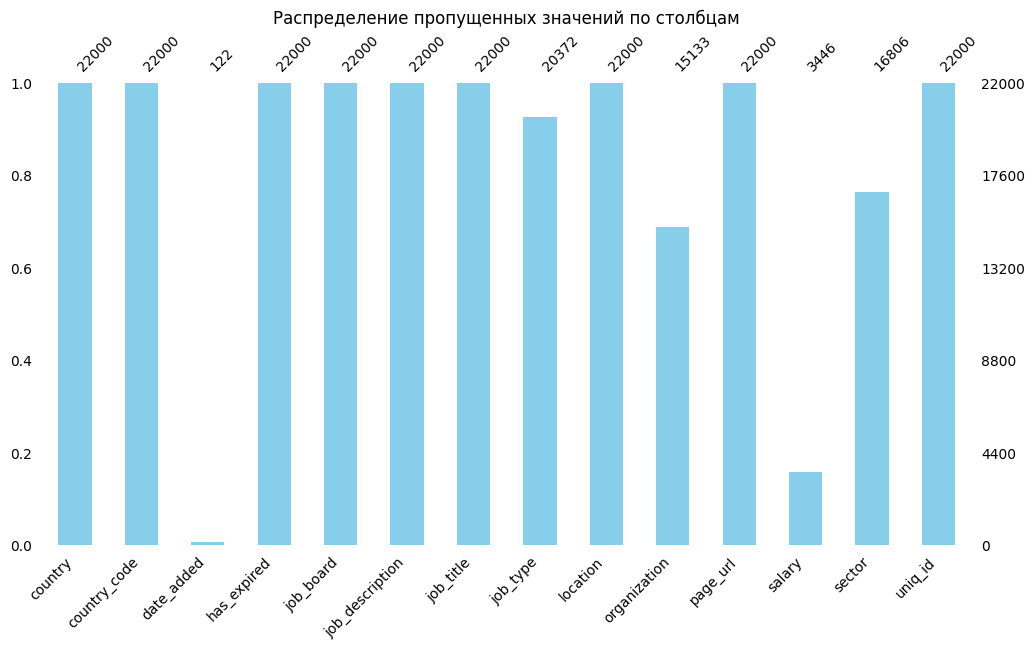

In [ ]:
missing_data = pd.DataFrame({
    'Total_Cells': df.shape[0],
    'Missing_Cells': df.isnull().sum()
})
missing_data['Percentage_Missing'] = (missing_data['Missing_Cells'] / missing_data['Total_Cells']) * 100
display(missing_data)

rows_with_many_nulls = missing_data['Percentage_Missing'] > 75
count_rows_with_many_nulls = rows_with_many_nulls.sum()
print(f"\nКоличество строк, в которых более 75% ячеек пусты: {count_rows_with_many_nulls}\n")

msno.bar(df, figsize=(12, 6), fontsize=10, color='skyblue')
plt.title('Распределение пропущенных значений по столбцам')
plt.show()

Проверьте, как изменится размер датасета, если принять решение удалить все строки, где есть пустые значения. Сделайте выводы.

In [ ]:
original_rows = df.shape[0]
df_dropped = df.dropna()
dropped_rows = df_dropped.shape[0]

print(f"Оригинальное количество строк: {original_rows}")
print(f"Количество строк после удаления всех строк с пропусками: {dropped_rows}")
print(f"Удалено строк: {original_rows - dropped_rows}")
print(f"Процент удаленных строк: {((original_rows - dropped_rows) / original_rows) * 100:.2f}%")

Оригинальное количество строк: 22000
Количество строк после удаления всех строк с пропусками: 5
Удалено строк: 21995
Процент удаленных строк: 99.98%


### Первичная оценка данных в столбцах

Изучите данные в столбцах датасета, ответив на следующие вопросы:
1. Есть ли столбцы, в которых встречается всего одно значение? Как их можно использовать в анализе?
2. Есть ли такие значения, которые встречаются более чем в одном столбце?
3. Есть ли столбцы, данные в которых не соответствуют названию столбца?

In [ ]:
# 1. Есть ли столбцы, в которых встречается всего одно значение?
# Можно удалить столбцы, они несут информацию только для мета-обзора, для сравнения с другими данными.
single_value_cols = []
for col in df.columns:
  unique_values = df[col].dropna().unique()
  if len(unique_values) == 1:
    single_value_cols.append(col)
    print(f"Столбец '{col}': Единственное значение - {unique_values[0]}")

# 2. Есть ли такие значения, которые встречаются более чем в одном столбце?
unique_values = {}
for col in df.columns:
  unique_values[col] = set(df[col].dropna().astype(str).str.lower())

all_common_values = []
for col1 in unique_values:
  for col2 in unique_values:
    if col1 != col2:
      common_values = unique_values[col1].intersection(unique_values[col2])
      if common_values:
        print(f"Есть общие значения между {col1} и {col2}: {list(common_values)}")
        all_common_values.append([col1, col2, common_values])


# 3. Есть ли столбцы, данные в которых не соответствуют названию столбца?
# 'salary': должен быть числовым, но содержит строковые значения в разных форматах
# 'sector': иногда содержит информацию об опыте, а не о сфере деятельности
# 'organization': содержит сферу работы организации а не имя как указано в описании. Иногда содержит 'All'
# 'job_type': содержит 'Full time' и 'Full time employee'

Столбец 'country': Единственное значение - United States of America
Столбец 'country_code': Единственное значение - US
Столбец 'has_expired': Единственное значение - No
Столбец 'job_board': Единственное значение - jobs.monster.com
Есть общие значения между job_description и job_title: ['please apply only if you are qualified.']
Есть общие значения между job_description и location: ['« back learn more juniper/cisco support job #: \xa0672302we currently have an urgent need for 5 network engineers at three different levels. we are in need of a juniper network engineer, 2 cisco network engineers, as well as 2 network engineers with wan and firewall experience. the job description is below. if you are interested in being submitted for one of the three roles, please reach out to anna morrow.\xa0phone: 804-545-7750email: amorrow@apexsystemsinc.com \xa0job title: network engineer\xa0rate: based on previous experience\xa0location: remote but must be willing to travel to the client sites\xa0cont

### Дублирование данных

Для поиска дублирующихся строк выполните следующие действия:
1. В таблице есть столбец `uniq_id`, значения которого, как сказано в описании данных, являются уникальными идентификаторами записей. Проверьте, действительно ли в этом столбце все значения различны.
2. Проверьте, есть ли в таблице другие столбцы, значения которых в каждой строке различны.
3. Если игнорировать столбцы, где все значения различны, найдутся ли такие строки, для которых значения по всем остальным столбцам будут совпадать?

Оцените результаты поиска дубликатов.

In [ ]:
# 1. Проверка уникальности столбца `uniq_id`
if df['uniq_id'].nunique() == df.shape[0]:
  print("Все значения в столбце 'uniq_id' уникальны.")
else:
  print(f"Количество уникальных 'uniq_id': {df['uniq_id'].nunique()} из {df.shape[0]} строк.")


# 2. Проверка других столбцов, значения которых в каждой строке различны
unique_columns = []
for col in df.columns:
  if col == 'uniq_id':
    continue
  if df[col].nunique() == df.shape[0]:
    unique_columns.append(col)
    print(f"Столбец '{col}' содержит только уникальные значения.")

if not unique_columns:
  print("Других столбцов с полностью уникальными значениями не найдено.")

# 3. Поиск дубликатов строк, игнорируя столбцы, где все значения различны
columns_to_check_for_duplicates = [col for col in df.columns if col not in unique_columns and col != 'uniq_id']


duplicate_rows_excluding_unique = df.duplicated(subset=columns_to_check_for_duplicates, keep=False)
num_duplicate_rows = duplicate_rows_excluding_unique.sum()

if num_duplicate_rows > 0:
    print(f"Найдено {num_duplicate_rows} дублирующихся строк, если не учитывать полностью уникальные столбцы. \n")
else:
    print("Дубликатов строк не найдено.")

Все значения в столбце 'uniq_id' уникальны.
Столбец 'page_url' содержит только уникальные значения.
Найдено 2078 дублирующихся строк, если не учитывать полностью уникальные столбцы. 



# Практические задания

В этом разделе необходимо обработать значения в трех столбцах датасета: `location`, `salary` и `job_type`. Цель обработки – стандартизировать данные в каждом из столбцов так, чтобы их можно было анализировать.

### Задание 1

В задании 1 необходимо провести обработку столбца `location`.

#### Задание 1.1

В столбце `location` представлена информация о местоположении организации, в которой открыта вакансия. Каждое значение столбца `location` содержит информацию о городе, коде штата и почтовом индексе.

Однако не в каждой строке есть все три характеристики местоположения, а также могут встречаться разные комбинации из них, записанные в виде строки в произвольном порядке и с разными разделителями.

Например, может быть указан только код штата, только название города или только индекс. Могут быть указаны любые две характеристики из трех.

**Формулировка задания:**
1. Определите, какие форматы встречаются.
2. Напишите одно или несколько регулярных выражений для поиска выявленных форматов.
3. Визуализируйте количество найденных форматов на столбчатой или круговой диаграмме. Также покажите на ней количество строк, в которых формат определить не удалось. Какие форматы встречаются чаще всего?

Ознакомиться с теоретическим материалом по работе с регулярными выражениями можно [по ссылке](https://colab.research.google.com/drive/1eFHdmt9OROLEDJRNc2wNmz0gpE1O3sKU?usp=sharing).


Выявленные форматы в столбце 'location' и их количество:
location_format
City, State Code, ZIP    11863
City, State Code          8271
City                      1023
City, ZIP                  335
ZIP                        254
State Code                 231
State Code, ZIP             23
Name: count, dtype: int64


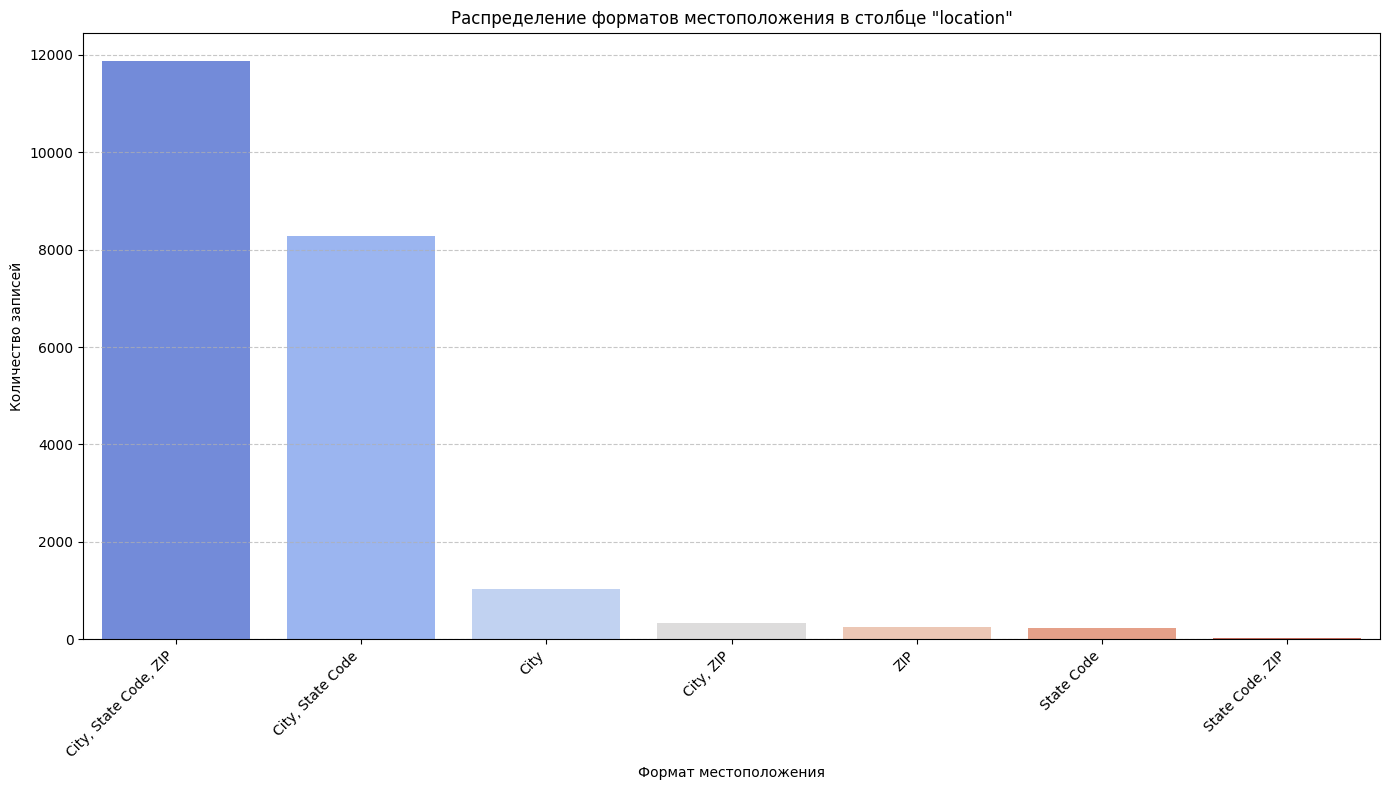

In [ ]:
def parse_location_components(location_str):
  if pd.isna(location_str) or str(location_str).strip() == '':
      return None, None, None, 'Missing'

  original_str = str(location_str).strip()

  zip_code = re.search(r'\b(\d{5})\b', original_str)
  zip_code = zip_code.group(1) if zip_code else None

  upper_str = original_str.upper()
  state_candidates = re.findall(r'\b([A-Z]{2})\b', upper_str)
  state_code = None
  if state_candidates and state_candidates[0] != zip_code:
      state_code = state_candidates[0]

  cleaned = re.sub(r'[,/#&@-]', ' ', original_str)
  if zip_code:
      cleaned = re.sub(rf'\b{re.escape(zip_code)}\b', '', cleaned, flags=re.IGNORECASE)
  if state_code:
      cleaned = re.sub(rf'\b{state_code}\b', '', cleaned, flags=re.IGNORECASE)
  city = re.sub(r'\s+', ' ', cleaned).strip() or None

  if city and not state_code and re.fullmatch(r'[A-Z]{2}', city):
      state_code = city
      city = None
  if city and not zip_code and re.fullmatch(r'\d{5}', city):
      zip_code = city
      city = None

  parts = []
  if city: parts.append("City")
  if state_code: parts.append("State Code")
  if zip_code: parts.append("ZIP")
  format_type = ", ".join(parts) if parts else "Unidentified"

  return city, state_code, zip_code, format_type

df_location_parsed = df['location'].apply(lambda x: pd.Series(parse_location_components(x), index=[
    'extracted_city', 'extracted_state_code', 'extracted_zip', 'location_format'
    ]))

df = pd.concat([df, df_location_parsed], axis=1)

format_counts = df['location_format'].value_counts()

print("\nВыявленные форматы в столбце 'location' и их количество:")
print(format_counts)


plt.figure(figsize=(14, 8))
sns.barplot(x=format_counts.index, y=format_counts.values, hue=format_counts.index, palette='coolwarm')
plt.title('Распределение форматов местоположения в столбце "location"')
plt.xlabel('Формат местоположения')
plt.ylabel('Количество записей')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Задание 1.2

В большей части строк удалось извлечь данные из ячейки столбца `location`, но остались и такие, где это не получилось. Вынесите в отдельный датасет записи, в которых не удалось определить формат записи информации о местоположении.

Над оставшимися строками проведите следующие преобразования:
1. Данные о местоположении разделите на 3 столбца: город, код штата, почтовый индекс.
2. Так как значения в столбце `почтовый индекс` являются пятизначными числами, преобразуйте их в целочисленный формат.

In [ ]:
# 1. Вынесение записей с неопределенным форматом в отдельный датасет
df_unidentified_locations = df[df['location_format'] == 'Unidentified'].copy()
print(f"Количество записей, в которых формат местоположения не удалось определить: {len(df_unidentified_locations)}")

df_locations_processed = df[df['location_format'] != 'Unidentified'].copy()

# 2. Разделение данных о местоположении на 3 столбца: город, код штата, почтовый индекс
df_locations_processed = df_locations_processed[['extracted_city', 'extracted_state_code', 'extracted_zip']].copy()
df_locations_processed.rename(columns={
    'extracted_city': 'city',
    'extracted_state_code': 'state_code',
    'extracted_zip': 'zip_code'
}, inplace=True)

# 3. Преобразование почтового индекса в целочисленный формат
df_locations_processed['zip_code'] = pd.to_numeric(df_locations_processed['zip_code'], errors='coerce').astype(pd.Int64Dtype())

print("\nПервые 5 строк обработанного датасета с местоположениями:")
display(df_locations_processed.head())

Количество записей, в которых формат местоположения не удалось определить: 0

Первые 5 строк обработанного датасета с местоположениями:


,city,state_code,zip_code
0,Madison,WI,53702
1,Madison,WI,53708
2,DePuy Synthes Companies a member of Johnson Jo...,IS,<NA>
3,Dixon,CA,<NA>
4,Camphill,PA,<NA>


Рассмотрите отложенную часть выборки (ту, где не удалось данные из столбца `location` разделить на три поля) и сделайте выводы о возможности извлечь из данных город, код штата и почтовый индекс. Извлеките все, что возможно. Что невозможно – оставьте пустым.

### Задание 2

В задании 2 необходимо провести обработку столбца `salary`.

#### Задание 2.1

В столбце `salary`, как и в `location`, данные не стандатизированы. В нем в основном можно встретить записи в следующих форматах:

* 10.00 - 20.00 &dollar; &sol;hour
* 10,000.00 - 20,000.00 &dollar; &sol;year
* &dollar;10.00 &sol;hour
* &dollar;10,000.00+ &sol;year
* Up to &dollar;20,000.00

Основные проблемы, которые стоит учесть при обработке форматов:
- В каждом из форматов может быть или не быть знака доллара.
- Может отсутствовать информация о периоде, за который указывается зарплата (`/hour` или `/year` в примерах).
- Зарплата может быть указана за месяц (`/month`) и за неделю (`/week`).
- В начале, конце и середине некоторых строк есть лишние пробелы, которые не стоит учитывать.

**Задание:**
1. Определите весь перечень встречающихся форматов и напишите одно или несколько регулярных выражений для их поиска.
2. Покажите на столбчатой диаграмме количество записей, содержащих каждый из форматов. Сделайте выводы.


Выявленные форматы в столбце 'salary' и их количество:
salary_format
Missing                     18554
Range , year                 1582
Range , hour                 1054
Unidentified                  361
Up to Single , No Period      100
Single Plus , year             89
Single Plus , hour             79
year                           57
Single Value , No Period       28
Range , month                  24
hour                           15
Range , day                    13
Range , No Period              11
Single Value , week            10
Range , week                    7
day                             4
Single Plus , No Period         4
Single Value , day              2
Single Plus , week              1
Single Plus , day               1
Up to Single , hour             1
No Period                       1
Single Value , hour             1
week                            1
Name: count, dtype: int64


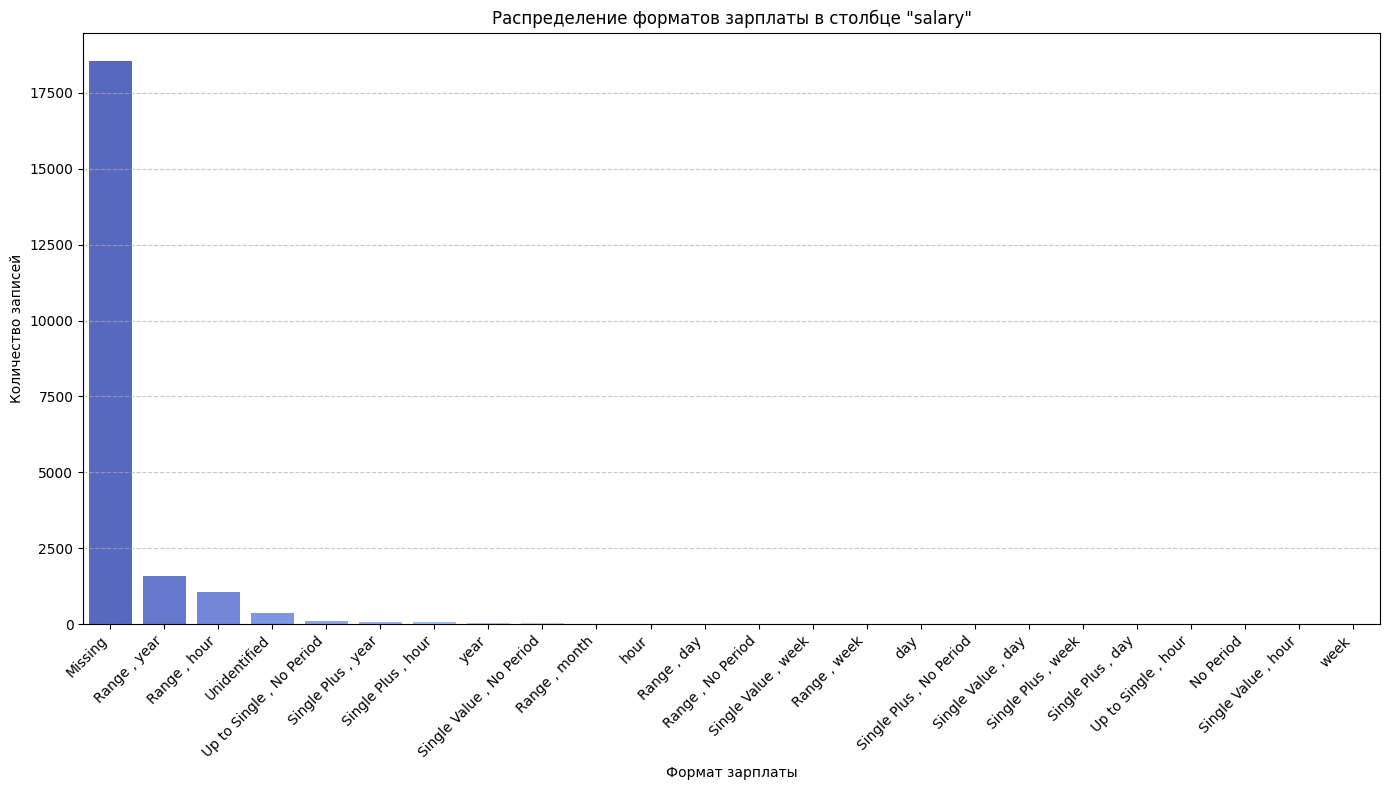

In [ ]:
def parse_salary_format(salary_str):
    if pd.isna(salary_str):
        return 'Missing'

    s = str(salary_str).strip().lower()

    s = s.replace(',', '')
    s = s.replace('$', '')
    s = re.sub(r'\s+', ' ', s)

    periods_map = {
        '/hour': 'hour',
        '/hr': 'hour',
        'hour': 'hour',
        '/day': 'day',
        'day': 'day',
        '/week': 'week',
        'week': 'week',
        '/month': 'month',
        'month': 'month',
        '/year': 'year',
        '/yr': 'year',
        'year': 'year'
    }
    found_period = None
    for p_str, p_name in periods_map.items():
        if p_str in s:
            found_period = p_name
            s = s.replace(p_str, '').strip()
            break

    is_up_to = 'up to' in s
    if is_up_to:
        s = s.replace('up to', '').strip()

    is_plus = '+' in s
    if is_plus:
        s = s.replace('+', '').strip()

    numbers = re.findall(r'\d+(?:\.\d+)?', s)
    try:
        numbers = [float(num) for num in numbers]
    except ValueError:
        numbers = []

    format_parts = []

    if len(numbers) == 2:
        format_parts.append('Range')
    elif len(numbers) == 1:
        if is_up_to:
            format_parts.append('Up to Single')
        elif is_plus:
            format_parts.append('Single Plus')
        else:
            format_parts.append('Single Value')
    elif len(numbers) == 0:
        return 'Unidentified'

    if found_period:
        format_parts.append(found_period)
    else:
        format_parts.append('No Period')

    return ' , '.join(format_parts)

df['salary_format'] = df['salary'].apply(parse_salary_format)

format_counts = df['salary_format'].value_counts()

print("\nВыявленные форматы в столбце 'salary' и их количество:")
print(format_counts)

plt.figure(figsize=(14, 8))
sns.barplot(x=format_counts.index, y=format_counts.values, hue=format_counts.index, palette='coolwarm')
plt.title('Распределение форматов зарплаты в столбце "salary"')
plt.xlabel('Формат зарплаты')
plt.ylabel('Количество записей')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#### Задание 2.2

1. Разделите столбец `salary` зарплаты три: `минимальная граница зарплаты`, `максимальная граница зарплаты`, `период`. Если значение суммы указано только одно, считайте, что это минимальная зарплата. Значение суммы в обоих столбцах преобразуйте в формат `float`.
2. Покажите на столбчатой диаграмме с группировкой среднюю и медианную минимальную зарплату в каждом периоде. Сделайте выводы.

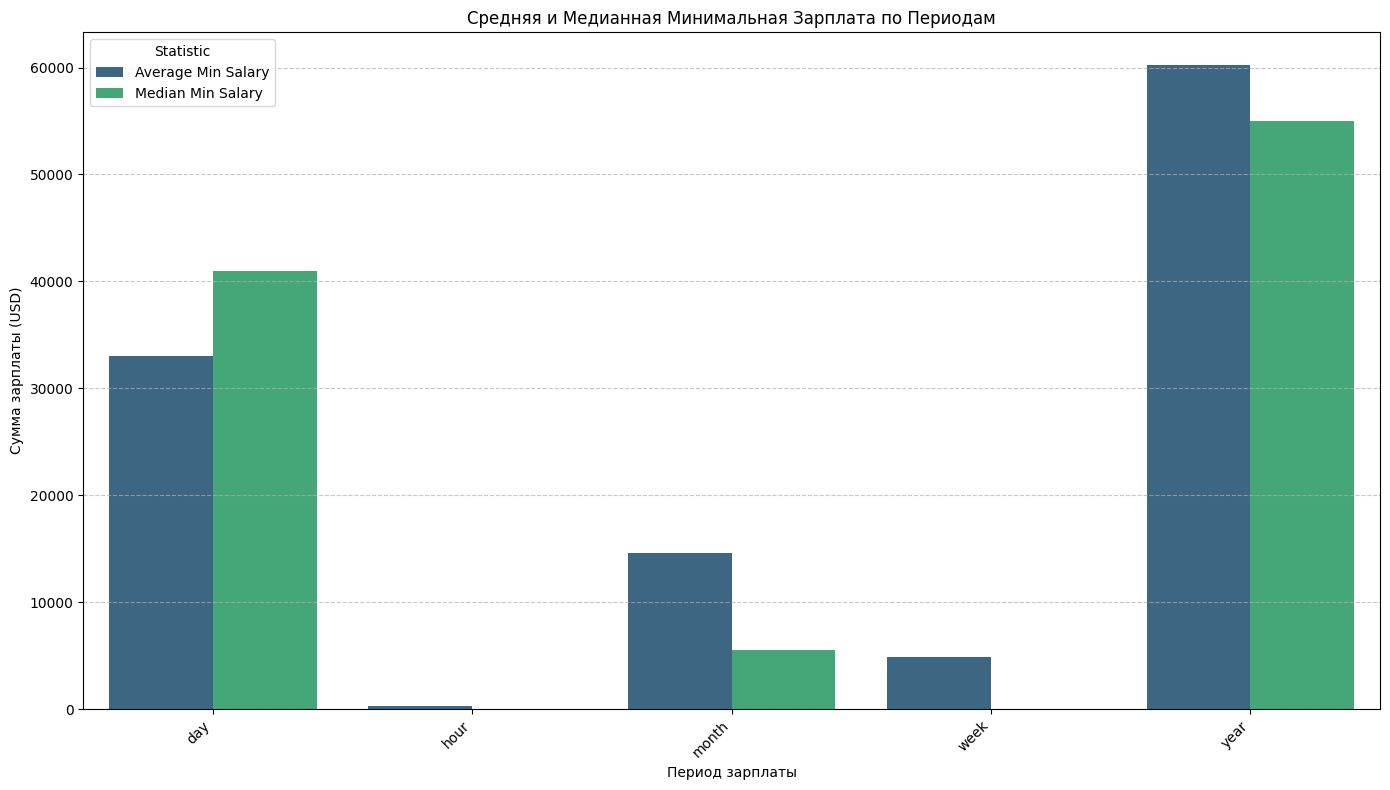

In [ ]:
def parse_salary_to_components(row):
  salary_str = str(row['salary']).strip().lower() if pd.notna(row['salary']) else None
  salary_format = row['salary_format']

  min_salary = np.nan
  max_salary = np.nan
  period = None

  if salary_str is None or salary_format == 'Missing' or salary_format == 'Unidentified':
    return min_salary, max_salary, period

  period_parts = salary_format.split(' , ')
  if len(period_parts) > 1 and period_parts[-1] != 'No Period':
    period = period_parts[-1]

  clean_str = salary_str.replace(',', '').replace('$', '').replace('up to', '').replace('+', '').strip()
  numbers = re.findall(r'\d+(?:\.\d+)?', clean_str)
  numbers = [float(num) for num in numbers]

  if 'Range' in salary_format and len(numbers) == 2:
    min_salary = min(numbers)
    max_salary = max(numbers)
  elif 'Single Value' in salary_format or 'Single Plus' in salary_format or ('No Period' in salary_format and len(numbers) == 1):
    min_salary = numbers[0] if numbers else np.nan
  elif 'Up to Single' in salary_format and len(numbers) == 1:
    max_salary = numbers[0] if numbers else np.nan

  return min_salary, max_salary, period

df[['min_salary', 'max_salary', 'salary_period']] = df.apply(parse_salary_to_components, axis=1, result_type='expand')

df['min_salary'] = pd.to_numeric(df['min_salary'], errors='coerce')
df['max_salary'] = pd.to_numeric(df['max_salary'], errors='coerce')


salary_stats = df.groupby('salary_period')['min_salary'].agg(['mean', 'median']).reset_index()
salary_stats.rename(columns={'mean': 'Average Min Salary', 'median': 'Median Min Salary'}, inplace=True)

salary_stats_melted = salary_stats.melt(id_vars='salary_period', var_name='Statistic', value_name='Amount')

plt.figure(figsize=(14, 8))
sns.barplot(x='salary_period', y='Amount', hue='Statistic', data=salary_stats_melted, palette='viridis')
plt.title('Средняя и Медианная Минимальная Зарплата по Периодам')
plt.xlabel('Период зарплаты')
plt.ylabel('Сумма зарплаты (USD)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#### Задание 2.3

Как было отмечено в задании 2.1, период, за который указывается зарплата, может отсутствовать. Восполните этот пробел в данных следующим образом:

1. Определите диапазон изменения (разброс) значений денежной суммы за каждый из встречающихся в данных периодов. Постройте гистограмму для каждого периода.
2. Определите, к среднему значению за какой период ближе всего сумма, у которой период не указан. Укажите для найденный период. В спорных случаях, где сумма одинаково близка к нескольким диапазонам, не выбирайте ничего.

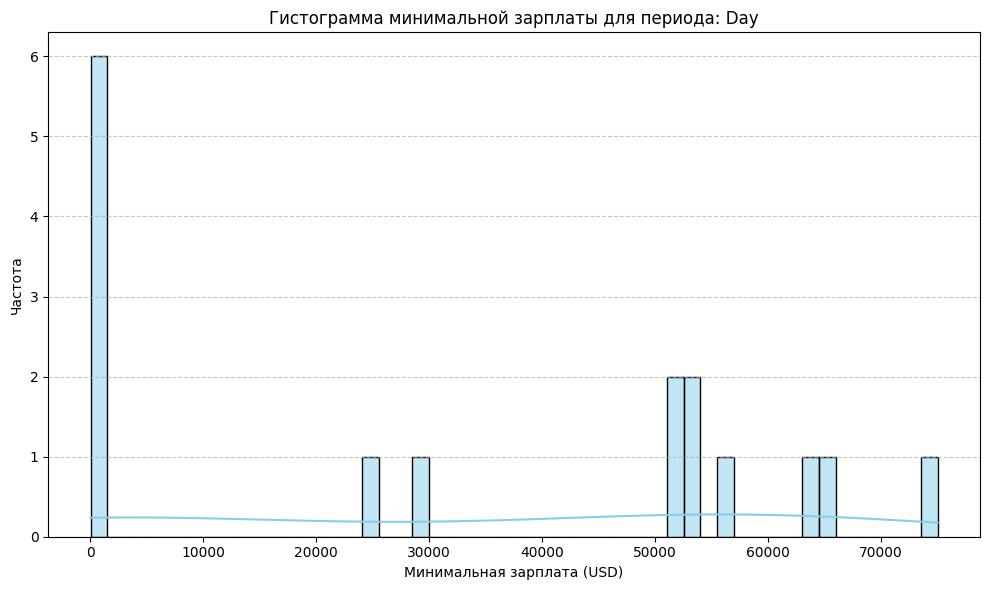

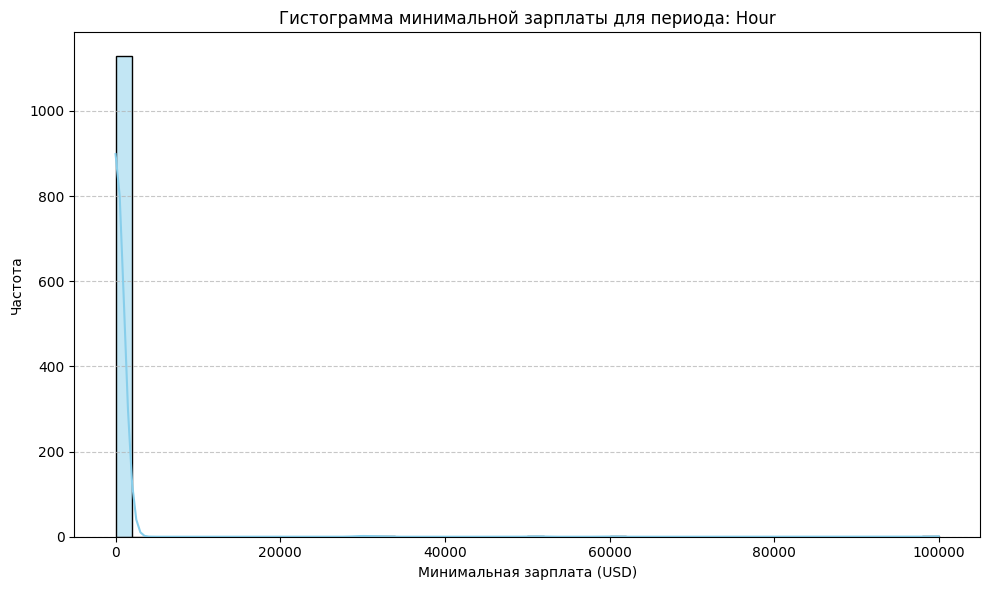

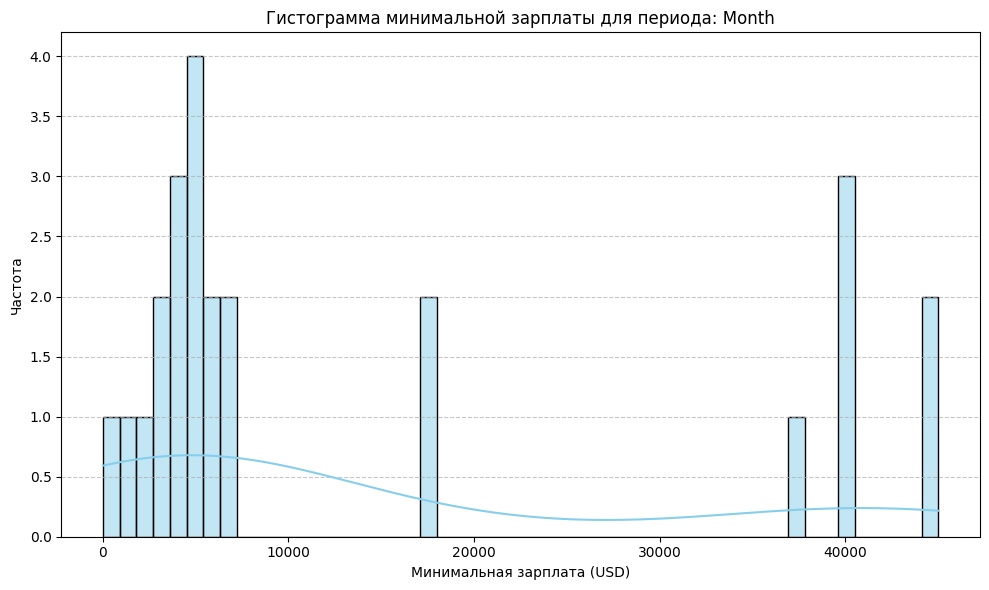

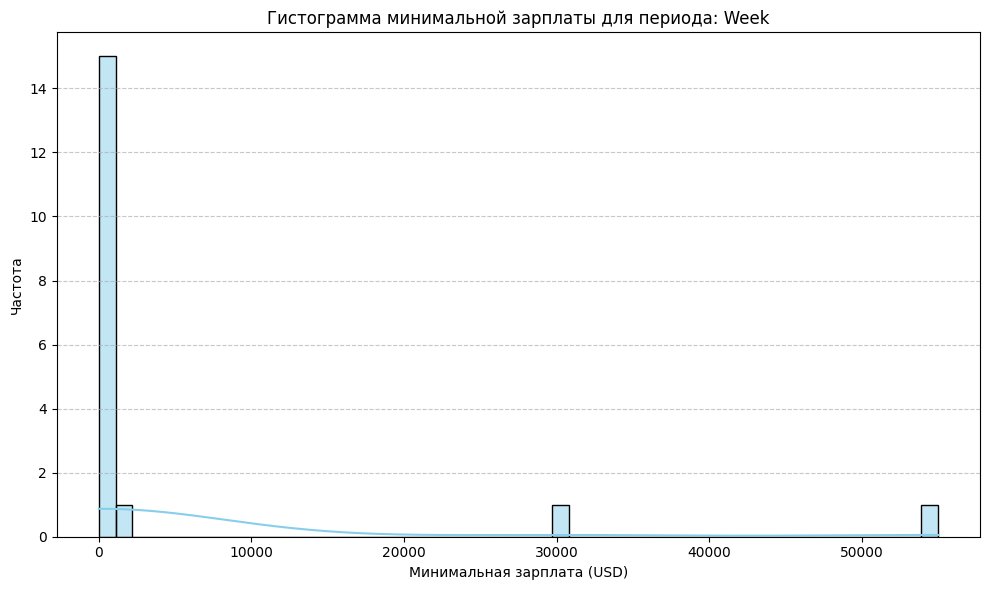

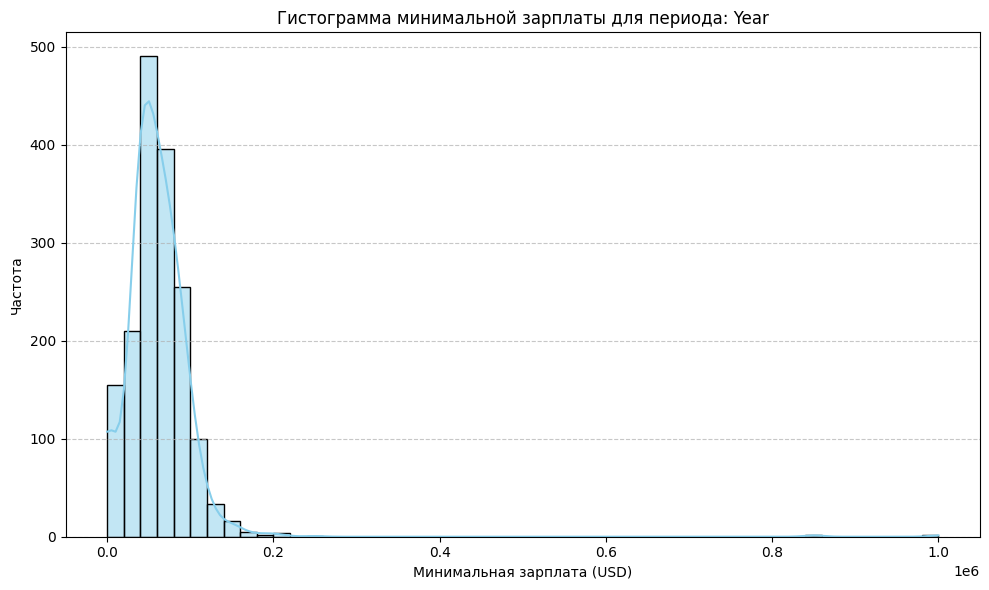

Нет записей с отсутствующим периодом зарплаты для восполнения.


In [ ]:
exclude_periods = ['No Period', 'Missing', 'Unidentified']
known_periods_mask = ~df['salary_period'].isin(exclude_periods)
valid_data = df[known_periods_mask & df['min_salary'].notna()]

period_stats = valid_data.groupby('salary_period')['min_salary'].agg(
    count='count',
    min='min',
    max='max',
    mean='mean',
    median='median'
).round(2)

known_periods = period_stats.index.tolist()
average_min_salaries = period_stats['mean'].to_dict()

for period in known_periods:
    stats = period_stats.loc[period]

    period_salaries = valid_data[valid_data['salary_period'] == period]['min_salary']
    plt.figure(figsize=(10, 6))
    sns.histplot(period_salaries, bins=50, kde=True, color='skyblue')
    plt.title(f'Гистограмма минимальной зарплаты для периода: {period.capitalize()}')
    plt.xlabel('Минимальная зарплата (USD)')
    plt.ylabel('Частота')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


no_period_mask = (df['salary_period'] == 'No Period') & df['min_salary'].notna()
df_no_period = df[no_period_mask].copy()

if not df_no_period.empty:
    no_period_salaries = df_no_period['min_salary'].values
    avg_salaries = np.array(list(average_min_salaries.values()))
    periods_list = list(average_min_salaries.keys())

    diffs = np.abs(no_period_salaries[:, np.newaxis] - avg_salaries)
    closest_indices = np.argmin(diffs, axis=1)

    imputed_count = 0
    for i, (idx, closest_idx) in enumerate(zip(df_no_period.index, closest_indices)):
        df.loc[idx, 'salary_period'] = periods_list[closest_idx]
        imputed_count += 1

    print(f"\nКоличество успешно восполненных периодов: {imputed_count}")


else:
    print("Нет записей с отсутствующим периодом зарплаты для восполнения.")


### Задание 3

В задании 3 необходимо провести обработку столбца `job_type`. Выясните, какие форматы значений есть в столбце `job_type`. Сделайте выводы. При необходимости – стройте графики.

Форматы значений в столбце 'job_type' и их количество:
job_type
Full Time                                        6757
Full Time Employee                               6617
Full Time, Employee                              3360
NaN                                              1628
Full Time Temporary/Contract/Project             1062
Full Time, Temporary/Contract/Project             533
Full Time , Employee                              406
Part Time Employee                                382
Part Time                                         329
Part Time, Employee                               196
Temporary/Contract/Project                        193
Employee                                          147
Full Time / Employee                              121
Full Time , Temporary/Contract/Project             56
Part Time, Temporary/Contract/Project              34
Per Diem, Employee                                 29
Per Diem                                           22
Job Type Full Time

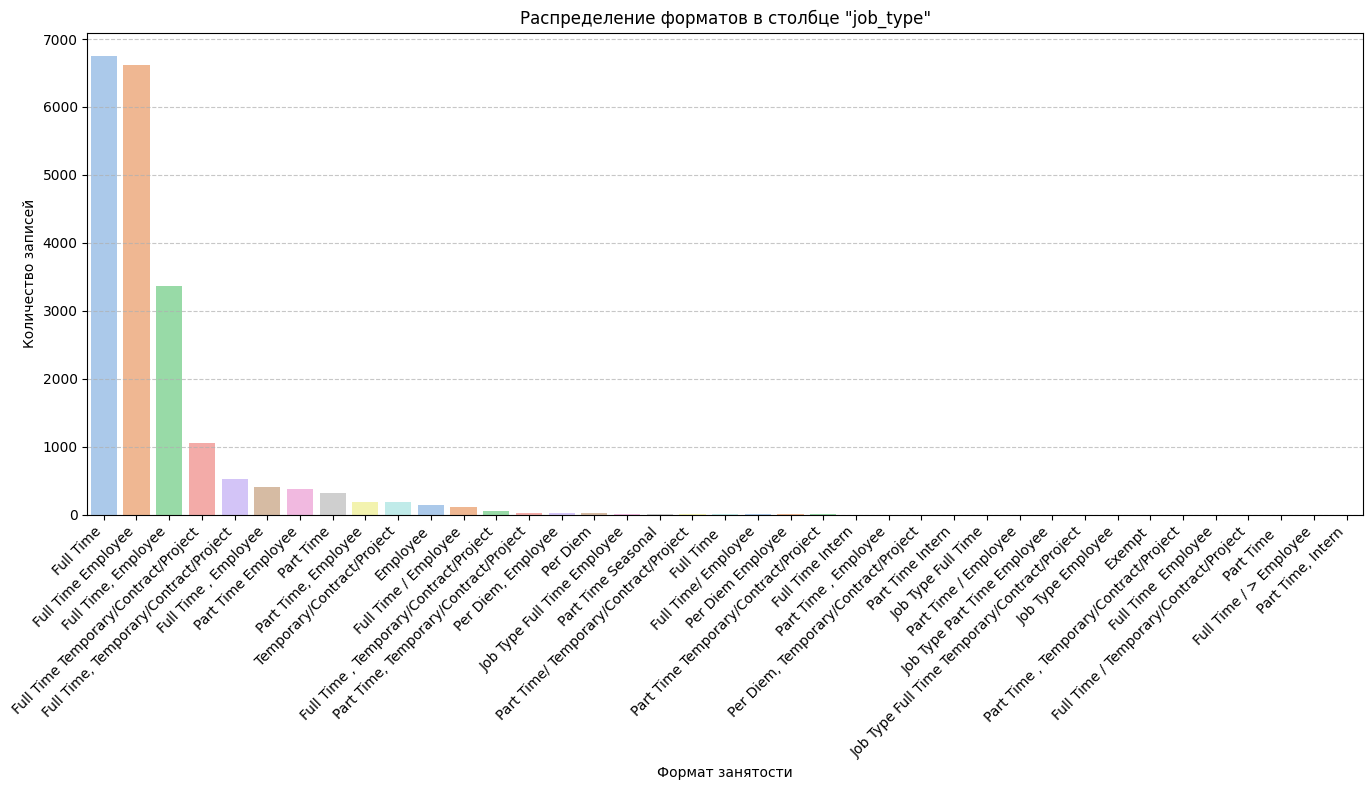

In [ ]:
# 1. Выясняем, какие форматы значений есть в столбце job_type
job_type_counts = df['job_type'].value_counts(dropna=False)

print("Форматы значений в столбце 'job_type' и их количество:")
print(job_type_counts)

plt.figure(figsize=(14, 8))
sns.barplot(x=job_type_counts.index, y=job_type_counts.values, hue=job_type_counts.index, palette='pastel', legend=False)
plt.title('Распределение форматов в столбце "job_type"')
plt.xlabel('Формат занятости')
plt.ylabel('Количество записей')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Вы заметили, что многие значения фактически одинаковые, но немного по-разному отформатированы? Приведем их к единому формату.

Распределение форматов в столбце 'job_type_cleaned' после стандартизации:
job_type_cleaned
Full Time                     18970
NaN                            1776
Part Time                       993
Temporary/Contract/Project      193
Per Diem                         67
Exempt                            1
Name: count, dtype: int64


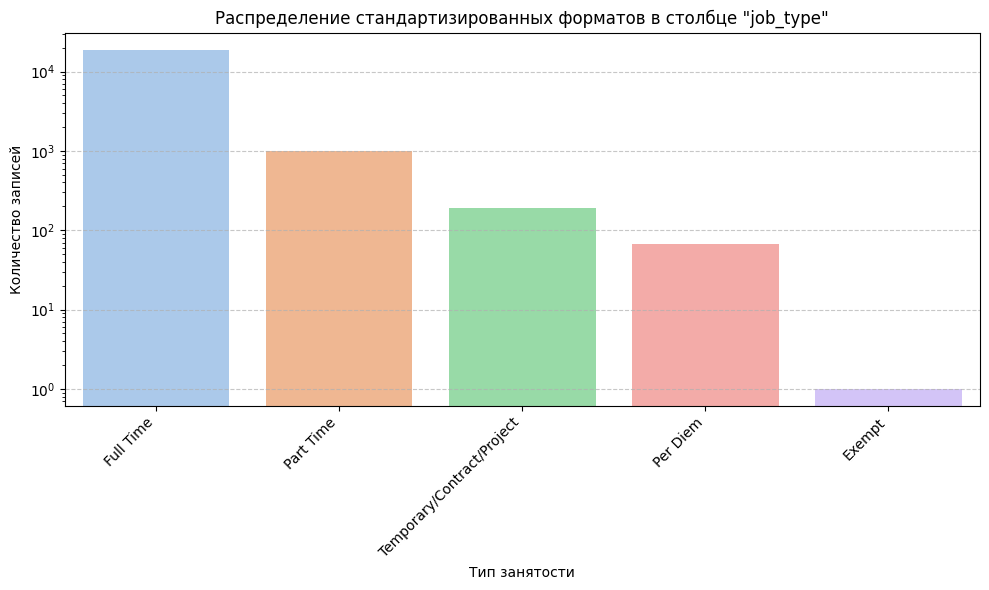

In [ ]:
def clean_job_type(job_type_str):
  if pd.isna(job_type_str):
    return np.nan

  s = str(job_type_str).strip().lower()

  s = s.replace('job type', '').replace('employee', '').strip()
  s = s.replace('temporary/contract/project', 'contract').strip()
  s = s.replace('/ employee', '').strip()
  s = re.sub(r'\s+', ' ', s)

  if 'full time' in s:
    return 'Full Time'
  elif 'part time' in s:
    return 'Part Time'
  elif 'per diem' in s:
    return 'Per Diem'
  elif 'contract' in s or 'temporary' in s or 'project' in s:
    return 'Temporary/Contract/Project'
  elif 'intern' in s:
    return 'Intern'
  elif 'exempt' in s:
    return 'Exempt'
  elif 'employee' in s:
    return 'Employee'
  elif s == '':
    return np.nan
  else:
    return 'Other'

df['job_type_cleaned'] = df['job_type'].apply(clean_job_type)

print("Распределение форматов в столбце 'job_type_cleaned' после стандартизации:")
cleaned_job_type_counts = df['job_type_cleaned'].value_counts(dropna=False)
print(cleaned_job_type_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=cleaned_job_type_counts.index, y=cleaned_job_type_counts.values, hue=cleaned_job_type_counts.index, palette='pastel', legend=False)
plt.title('Распределение стандартизированных форматов в столбце "job_type"')
plt.xlabel('Тип занятости')
plt.ylabel('Количество записей')
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Столбец `job_type` состоит из двух частей: "полнота" занятости (`Full Time`, `Part Time`, `Per Diem`) и "тип" занятости (`Employee`, `Intern`). Кроме того, встречаются и неполные записи.

Задание:
1. Написать одно или несколько регулярных выражений для разделения столбца `job_type` на два: `полнота занятости`, `тип занятости`.
2. Если данные о полноте отсутствуют, внесите значение `Full Time`.
Если отсутствуют данные о типе – внесите `Employee`.
3. Постройте столбчатую диаграмму со стековой группировкой для полноты и типа занятости. Сделайте выводы.


Распределение полноты занятости:


,count
employment_fullness,
Full Time,20940
Part Time,993
Per Diem,67



Распределение типа занятости:


,count
employment_type,
Employee,20084
Intern,1916


<Figure size 1400x800 with 0 Axes>

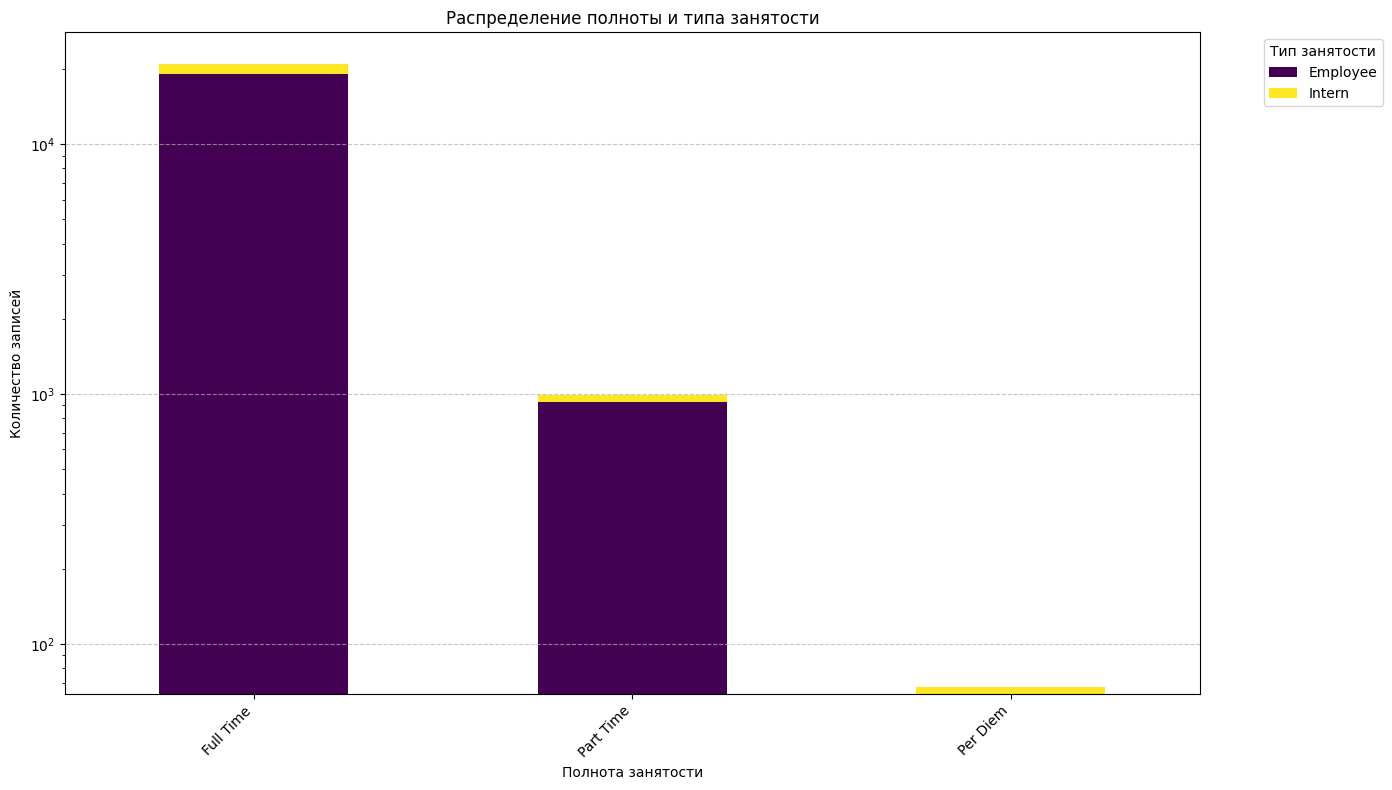

In [ ]:
def extract_job_components(job_type_str):
  if pd.isna(job_type_str):
    return np.nan, np.nan

  s = str(job_type_str).lower()

  fullness = None
  emp_type = None

  if re.search(r'full time', s):
    fullness = 'Full Time'
  elif re.search(r'part time', s):
    fullness = 'Part Time'
  elif re.search(r'per diem', s):
    fullness = 'Per Diem'

  if re.search(r'intern', s):
    emp_type = 'Intern'
  elif re.search(r'temporary/contract/project', s):
    emp_type = 'Intern'
  elif re.search(r'employee', s):
    emp_type = 'Employee'


  return fullness, emp_type

df[['employment_fullness', 'employment_type']] = df['job_type'].apply(lambda x: pd.Series(extract_job_components(x)))

df['employment_fullness'] = df['employment_fullness'].fillna('Full Time')

df['employment_type'] = df['employment_type'].fillna('Employee')

print("\nРаспределение полноты занятости:")
display(df['employment_fullness'].value_counts(dropna=False))

print("\nРаспределение типа занятости:")
display(df['employment_type'].value_counts(dropna=False))

stacked_data = df.groupby(['employment_fullness', 'employment_type']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
stacked_data.plot(kind='bar', stacked=True, figsize=(14, 8), cmap='viridis')
plt.title('Распределение полноты и типа занятости')
plt.xlabel('Полнота занятости')
plt.ylabel('Количество записей')
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Тип занятости', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Порядок защиты работы

**Для защиты работы необходимо:**
1. Предоставить результаты выполнения всех заданий в виде ссылки на Google Colab.
2. Выполнить дополнительное задание в процессе сдачи работы. Дополнительное задание представляет собой решение задачи на обработку данных лабораторной работы, меньшее по объему, но сопоставимое по сложности тем заданиям, которые требовалось выполнить в рамках работы.

**Примеры дополнительных заданий:**
1. В столбце `sector` часто представлены данные из столбца `organization` и наоборот. Устраните эту проблему.
2. В столбце `job_title` часто можно частично или полностью встретить указание местоположения организации. Сравните, совпадают ли в таких случаях данные с тем, что указано в столбцах `город`, `код штата`, `почтовый индекс`. Если в этих трех столбцах данные отсутствуют, заполните их данными из столбца `job_title`.
3. Практически во всех столбцах датасета вместо соответствующих названию данных иногда встречается текст из `job_description`. Найдите такие столбцы и записи с описанием вакансии в них. Покажите на столбчатой диаграмме, в каких столбцах и в каком количестве находится информация из столбца `job_description`.

# Дополнительные материалы

1. DAMA-DMBOK: Свод знаний по управлению данными: Второе издание / DAMA International; [пер. с англ.]. – Москва: ООО "Олимп-Бизнес", 2021. – 828 с.
2. Макгрегор, С. Обработка данных на Python: Data Wrangling и Data Quality: [Текст] / С. Макгрегор. – Москва: БХВ, 2024. – 432 с.